# Processamento de Linguagem Natural

In [1]:
from pathlib import Path


from dotenv import load_dotenv

import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from gensim import corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models.ldamodel import LdaModel

from nltk.stem import PorterStemmer, SnowballStemmer
from numpy.ma.core import left_shift
from seaborn import heatmap

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
DATASET_DIR = 'dataset'

ROOT_DIR = Path().resolve().__str__()
DATASET_PATH = Path(ROOT_DIR).joinpath(DATASET_DIR)

load_dotenv(ROOT_DIR + 'secrets.env')

False

In [3]:
!kaggle auth login

You are already logged-in to Kaggle as [renataabreu].
Please use the --force flag to override.


In [4]:
import kaggle

kaggle.api.authenticate()
Path.mkdir(Path(DATASET_PATH), parents=True, exist_ok=True)
kaggle.api.dataset_download_files('olistbr/brazilian-ecommerce', path=DATASET_PATH, unzip=True, quiet=False)

print("Path to dataset files: ", DATASET_PATH)

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


100%|██████████| 42.6M/42.6M [00:02<00:00, 17.0MB/s]



Path to dataset files:  C:\Users\Renata\DataspellProjects\Infnet-MIT-IA-PLN-PD_26E2_\dataset


## Normalização

In [5]:
reviews = pd.read_csv(DATASET_PATH.joinpath('olist_order_reviews_dataset.csv'), encoding='utf-8')
reviews.dropna(axis=0, subset=['review_comment_message'], inplace=True)
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01
...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43


In [6]:
import numpy as np

nltk.download('stopwords')

stop_words = stopwords.words('portuguese')
stop_words.extend(['nan'])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Renata\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
def clean_text_as_list(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return [token for token in tokens if token not in stop_words]

def clean_text_as_str(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return ' '.join((token for token in tokens if token not in stop_words))

Aplica o mesmo preprocessamento, porém o retorno é diferente para uso distintos (_list_ e _string_).

In [8]:
cols = ['review_comment_title', 'review_comment_message']
reviews['tokens'] = (reviews[cols].astype(str)
                     .apply(lambda x:
                                                 ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) is not None else str(x['review_comment_message']))]), axis=1)
                     .apply(clean_text_as_list))

In [9]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,tokens
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,"[recebi, bem, antes, prazo, estipulado]"
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,"[parabens, lojas, lannister, adorei, comprar, ..."
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,"[recomendo, aparelho, eficiente, site, marca, ..."
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,"[pouco, travando, valor, boa]"
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,"[super, recomendo, vendedor, confiavel, produt..."
...,...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51,"[produto, recebi, acordo, compra, realizada]"
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23,"[entregou, dentro, prazo, produto, chegou, con..."
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06,"[produto, nao, enviado, nao, existe, venda, ce..."
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,"[excelente, mochila, entrega, super, rapida, s..."


<Axes: >

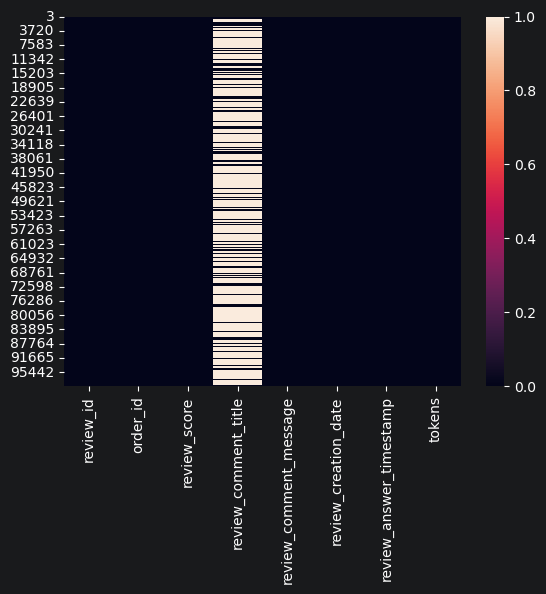

In [10]:
sb.heatmap(reviews.isna())

## Stemming / Snowball

In [11]:
!python -m spacy download pt_core_news_md

     ---------------------------------------- 0.0/42.4 MB ? eta -:--:--
     ------ --------------------------------- 7.1/42.4 MB 43.7 MB/s eta 0:00:01
     -------------- ------------------------ 16.0/42.4 MB 43.8 MB/s eta 0:00:01
     ----------------------- --------------- 25.4/42.4 MB 43.5 MB/s eta 0:00:01
     -------------------------- ------------ 28.6/42.4 MB 35.6 MB/s eta 0:00:01
     ---------------------------- ---------- 30.7/42.4 MB 30.4 MB/s eta 0:00:01
     ------------------------------ -------- 32.8/42.4 MB 26.3 MB/s eta 0:00:01
     -------------------------------- ------ 34.9/42.4 MB 24.1 MB/s eta 0:00:01
     --------------------------------- ----- 36.7/42.4 MB 22.4 MB/s eta 0:00:01
     ------------------------------------ -- 39.3/42.4 MB 21.2 MB/s eta 0:00:01
     ------------------------------------ -- 39.8/42.4 MB 21.1 MB/s eta 0:00:01
     ------------------------------------ -- 40.1/42.4 MB 18.0 MB/s eta 0:00:01
     --------------------------------------  41.

In [12]:
from collections import Counter
import spacy
snowball_pt = SnowballStemmer(language="portuguese")
nlp_pt = spacy.load("pt_core_news_md")
tokens_rad = []
for tokens in reviews['tokens']:
    for token in list(tokens):
        token = snowball_pt.stem(token)
        tokens_rad.append(token)

for tuple_tokens in Counter(tokens_rad).most_common(50):
    print(tuple_tokens)

('produt', 20919)
('nao', 12918)
('entreg', 12456)
('praz', 8663)
('compr', 7499)
('receb', 6805)
('cheg', 6607)
('recom', 6067)
('antes', 5680)
('bom', 5661)
('otim', 4857)
('vei', 3380)
('rap', 3143)
('bem', 3133)
('loj', 2943)
('qualidad', 2882)
('gost', 2597)
('sup', 2482)
('tud', 2479)
('aind', 2414)
('excelent', 2387)
('ate', 2093)
('ped', 2067)
('perfeit', 1641)
('esper', 1552)
('boa', 1524)
('dentr', 1476)
('satisfeit', 1436)
('atend', 1418)
('outr', 1348)
('dia', 1317)
('lannist', 1281)
('por', 1233)
('sit', 1212)
('previst', 1189)
('correi', 1136)
('parabens', 1126)
('tod', 1093)
('falt', 1072)
('cert', 1072)
('aguard', 1067)
('lind', 1065)
('problem', 1063)
('pois', 1050)
('corret', 1033)
('ador', 999)
('sempr', 979)
('demor', 979)
('conform', 956)
('obrig', 942)


## Lematização

In [13]:
reviews['review_comment_transformed'] = (reviews[cols].astype(str)
                     .apply(lambda x:
                                ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) != 'nan' else str(x['review_comment_message']))]), axis=1
                            )
       )

In [14]:
docs = (reviews['review_comment_transformed'].astype(str)
                    .apply(clean_text_as_str)
       )

In [15]:
tokens_lem = []

for doc in docs:
    lemanizer = nlp_pt(doc)
    for lem in lemanizer:
        tokens_rad.append(lem.lemma_)

for tuple_tokens in Counter(tokens_lem).most_common(50):
    print(tuple_tokens)

## Classificação

### Supervisionada com Naive Bayes e Vetorização com TfidfVectorizer

### Por Categorias

- 1 = Péssimo
- 2 = Ruim
- 3 = Regular
- 4 = Bom
- 5 = Excelente

In [35]:
categories = dict({
    1: 'Péssimo',
    2: 'Ruím',
    3: 'Regular',
    4: 'Bom',
    5: 'Excelente',
})

In [17]:
model = MultinomialNB()
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(categories.values())

model.fit(X, list(categories.keys()))

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [18]:
predictions_nm = []
rates_tf_idf = []
for review in docs:
    vec = vectorizer.transform([review])
    rates_tf_idf.append(model.predict(vec)[0])
    # rates_tf_idf.append({"tf-idf": model.predict(vec)[0]})
    predictions_nm.append({"review": review, "nota": model.predict(vec)[0], "categoria": categories.get(model.predict(vec)[0])})


### Por tokens (input dos compradores)

In [37]:
tokens_lem_by_rate = []
tokens_lem = []

_sample = pd.DataFrame(reviews).sample(frac=0.2, random_state=42)

for i, rate in enumerate(categories.keys()):
    filtered = _sample.query('review_score == ' + str(rate))
    for review in pd.DataFrame({'tokens': filtered.review_comment_transformed}).values:
        tokens = clean_text_as_str(review)
        lemanizer = nlp_pt(tokens)
        for lem in lemanizer:
            tokens_lem.append(lem.lemma_)
    tokens_lem_by_rate.append({'rate': rate, 'tokens': tokens_lem.copy()})
    tokens_lem.clear()

In [38]:
model_rate = MultinomialNB()
vectorizer_rate = TfidfVectorizer()

keys = list(pd.DataFrame(tokens_lem_by_rate)['rate'].apply(lambda x: str(x)))
values = list(pd.DataFrame(tokens_lem_by_rate)['tokens'].apply(lambda x: str(x)))
X_rate = vectorizer_rate.fit_transform(values)

model_rate.fit(X_rate, list(keys))

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [39]:
predictions_nm_rate = []
rates_tf_idf_rate = []
for review in docs:
    vec = vectorizer_rate.transform([review])
    _X = model_rate.predict(vec)
    rates_tf_idf_rate.append(int(_X[0]))
    # rates_tf_idf.append({"tf-idf": model.predict(vec)[0]})
    predictions_nm_rate.append({"review": review, "nota": _X[0], "categoria": categories.get(int(_X[0]))})

### Vetorizar por Rate (*)

In [22]:
# tokens_lem_by_rate = []
# tokens_lem = []
#
# for i, rate in enumerate(categories.keys()):
#     filtered = reviews.query('review_score == ' + str(rate))
#     tokens_lem.clear()
#     for review in pd.DataFrame({'tokens': filtered.review_comment_transformed}).values:
#         tokens = clean_text_as_str(review)
#         lemanizer = nlp_pt(tokens)
#         for lem in lemanizer:
#             tokens_lem.append(lem.lemma_)
#     tokens_lem_by_rate.append({'rate': rate, 'tokens': tokens_lem})

In [23]:
# analyzer = SentimentIntensityAnalyzer()
# WORDS_PER_CATEGORY = 30
#
# for tokens_lem_rate in iter(tokens_lem_by_rate):
#     print('rate: ' + tokens_lem_rate.get('rate').__str__())
#     for tuple_tokens in Counter(tokens_lem_rate.get('tokens')).most_common(WORDS_PER_CATEGORY):
#         print(tuple_tokens, end="\n")
#         analyzer.lexicon.update({
#             tuple_tokens.__getitem__(0): tokens_lem_rate.get('rate'),
#         })
#     print("\n")


In [24]:
# analyzer = SentimentIntensityAnalyzer()
# WORDS_PER_CATEGORY = 200
#
# import numpy.ma.core as math
#
# for tokens_lem_rate in iter(tokens_lem_by_rate):
#     print('rate: ' + tokens_lem_rate.get('rate').__str__())
#     for tuple_tokens in Counter(tokens_lem_rate.get('tokens')).most_common(WORDS_PER_CATEGORY):
#         _weight = math.power(float(tuple_tokens.__getitem__(1)),  float(tokens_lem_rate.get('rate')*-1))
#         print(tuple_tokens, end="\n")
#         _lex = analyzer.lexicon.get(tuple_tokens.__getitem__(0))
#         if _lex is None:
#             analyzer.lexicon.update({
#                 tuple_tokens.__getitem__(0): float(tokens_lem_rate.get('rate') + _weight) -1,
#             })
#         else:
#              analyzer.lexicon.update({
#                 tuple_tokens.__getitem__(0): float(_lex + _weight),
#             })
#     print("\n")


### VADER

In [25]:
analyzer = SentimentIntensityAnalyzer()

# adiciona palavras em português
analyzer.lexicon.update({

    "excelente": 5,
    "qualidade": 5,
    "parabens": 5,
    "rapido": 5,
    "recomendar": 5,
    "resistente": 5,
    "otimo": 5,
    "super": 5,

    "bom": 4,
    "recebi": 4,
    "chegou": 4,
    "boa": 4,
    "obrigado": 4,
    "bonito": 4,

    "funcionar": 3,

    "muito ruim": 2,
    "ruim": 2,
    "mal": 2,
    "danificar": 2,
    "defeito": 2,
    "pequeno": 2,

    "pessimo": 1,
    "problema": 1,
    "horrivel": 1,
    "errar": 1,
    "retornar": 1,
    "cancelei": 1,
    "cancelar": 2,
    "reembolso": 1,
    "devolucao": 1,
    "devolver": 1,
})

In [26]:
def compound_to_rating(compound):
    if compound <= -0.6:
        return 1
    elif compound <= -0.2:
        return 2
    elif compound <= 0.2:
        return 3
    elif compound <= 0.6:
        return 4
    else:
        return 5

In [27]:
rates_vader = []
predictions_vader = []
for review in docs:
    vader = analyzer.polarity_scores(review)
    compound = vader['compound']
    rating = compound_to_rating(compound)
    rates_vader.append(rating)

    predictions_vader.append({"review": review, "nota": rating, "categoria": categories.get(rating)})


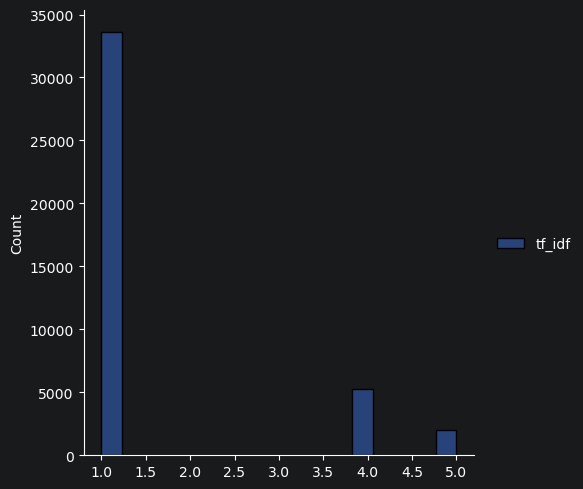

In [28]:
sb.displot(data=pd.DataFrame({'tf_idf': rates_tf_idf}))

In [29]:
pd.DataFrame(predictions_nm)

,review,nota,categoria
0,recebi bem antes prazo estipulado,1,Péssimo
1,parabens lojas lannister adorei comprar intern...,1,Péssimo
2,recomendo aparelho eficiente site marca aparel...,1,Péssimo
3,pouco travando valor boa,1,Péssimo
4,super recomendo vendedor confiavel produto ent...,1,Péssimo
...,...,...,...
40972,produto recebi acordo compra realizada,1,Péssimo
40973,entregou dentro prazo produto chegou condicoes...,1,Péssimo
40974,produto nao enviado nao existe venda certeza f...,1,Péssimo
40975,excelente mochila entrega super rapida super r...,5,Excelente


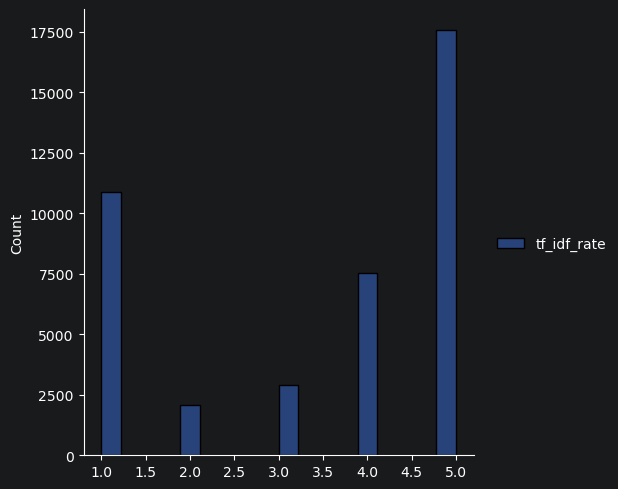

In [40]:
sb.displot(data=pd.DataFrame({'tf_idf_rate': rates_tf_idf_rate}))

In [31]:
pd.DataFrame(predictions_nm_rate).sample(frac=0.5)

,review,nota,categoria
7728,satisfacao total preco qualidade,5,Excelente
32673,acho periodo bom entrega dias outras lojas vcs...,4,Bom
2392,esposo recebeu interior mercadoria chegar vou ...,1,Péssimo
38891,ocorreu certo prazo entrega recomendo,5,Excelente
30879,excelente tudo normal beleza,5,Excelente
...,...,...,...
39086,nao recomendo,1,Péssimo
18360,produto lindo,4,Bom
1638,tudo feito conforme tratado contratado,5,Excelente
8464,site lojas lannister simplesmente melhor entre...,5,Excelente


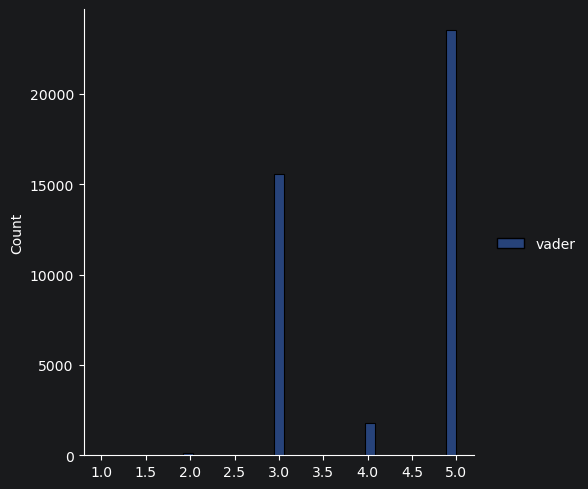

In [32]:
sb.displot(data=pd.DataFrame({'vader': rates_vader}))

In [33]:
pd.DataFrame(predictions_vader).sample(frac=0.5)

,review,nota,categoria
11831,super recomendado bom,5,Excelente
4171,tudo conforme prometido,3,Regular
127,bom,5,Excelente
2955,produto errado produto errado descricao dizia ...,5,Excelente
4961,superou expectativas,3,Regular
...,...,...,...
33143,inclusive recebi bem antes prazo entrega,5,Excelente
8242,bom,5,Excelente
37309,ainda nao produto pessoalmente prazo inicial e...,3,Regular
1071,tudo certo,3,Regular


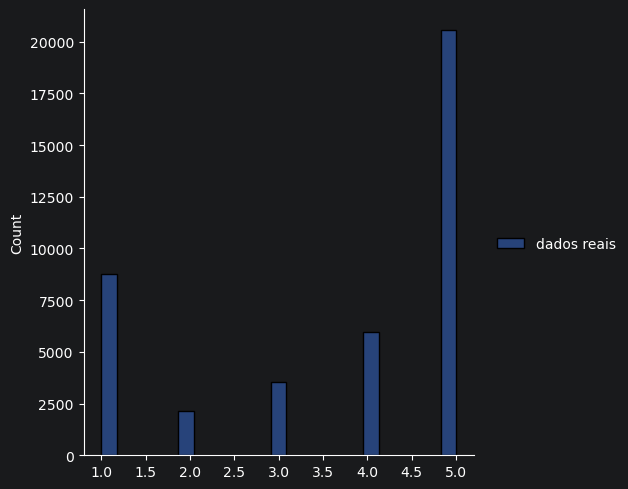

In [34]:
sb.displot(data=pd.DataFrame({'dados reais': reviews.review_score}))

### Comparação

| Método                                             | Análise                                                                                                                                                                                                                |
|----------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Naive Bayes / TF-IDF por Categoria                 | Não conseguiu categorizar, devido à falta de interpretação léxica e falta de variedade de tokens para categorizar.                                                                                                     |
| Naive Bayes / TF-IDF por Tokens (input de compradores) | Teve boa performance no treinamento, devido aos tokens serem coletados dos próprios compradores para realizar o treinamento, foi possível obter um resultado mais preciso, mesmo com ausência de interpretação léxica. |
| VADER                                              | Teve um desempenho médio, mesmo com a interpretação léxica. A falta de suporte nativo para a lingua portuguesa e a necessidade de input manual dos tokens é um desafio.                                                |